For an ε change (e.g. 1%) in total flux from magnification, what is the change in fiberflux? In other words, if fiberflux changes by fiber_factor*ε, what is multiplicative factor fiber_factor?

In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio

from scipy.interpolate import griddata
from scipy.signal import savgol_filter

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
from scipy import stats
from scipy.interpolate import interp1d, interp2d

def binned_mean(x, y, bins):
    from scipy import stats
    bin_center, bin_mean = np.full((2, len(bins)-1), np.nan)
    for index in range(len(bins)-1):
        mask = (x>=bins[index]) & (x<bins[index+1])
        if np.sum(mask)>0:
            bin_centex[index] = np.mean(x[mask])
            bin_mean[index] = np.mean(y[mask])
    return bin_center, bin_mean

In [4]:
photom_columns = ['MORPHTYPE', 'EBV', 'FLUX_G', 'FLUX_R', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2', 'FIBERFLUX_Z', 'SHAPE_R', 'SERSIC']
more_1_columns = ['SHAPE_E1', 'SHAPE_E2']

cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/combined/dr9_lrg_south_1.0.0_basic.fits'))
photom = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/combined/dr9_lrg_south_1.0.0_photom.fits', columns=photom_columns))
more_1 = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/combined/dr9_lrg_south_1.0.0_more_1.fits', columns=more_1_columns))
cat = hstack([cat, photom, more_1], join_type='exact')
print(len(cat))
south = cat.copy()

cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/combined/dr9_lrg_north_1.0.0_basic.fits'))
photom = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/combined/dr9_lrg_north_1.0.0_photom.fits', columns=photom_columns))
more_1 = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/combined/dr9_lrg_north_1.0.0_more_1.fits', columns=more_1_columns))
cat = hstack([cat, photom, more_1], join_type='exact')
print(len(cat))
north = cat.copy()

cat = vstack([south, north])
print(len(cat))

cat.rename_column('MORPHTYPE', 'TYPE')

9144035
3194955
12338990


In [5]:
maskbits = [1, 8, 9, 11, 12, 13]
mask_clean = np.ones(len(cat), dtype=bool)
for bit in maskbits:
    mask_clean &= (cat['MASKBITS'] & 2**bit)==0
print(np.sum(~mask_clean)/len(mask_clean))
cat = cat[mask_clean]
print(len(cat))

min_nobs = 2
mask = (cat['NOBS_G']>=min_nobs) & (cat['NOBS_R']>=min_nobs) & (cat['NOBS_Z']>=min_nobs)
cat = cat[mask]
print(len(cat))

0.10460434768161737
11048278
10579981


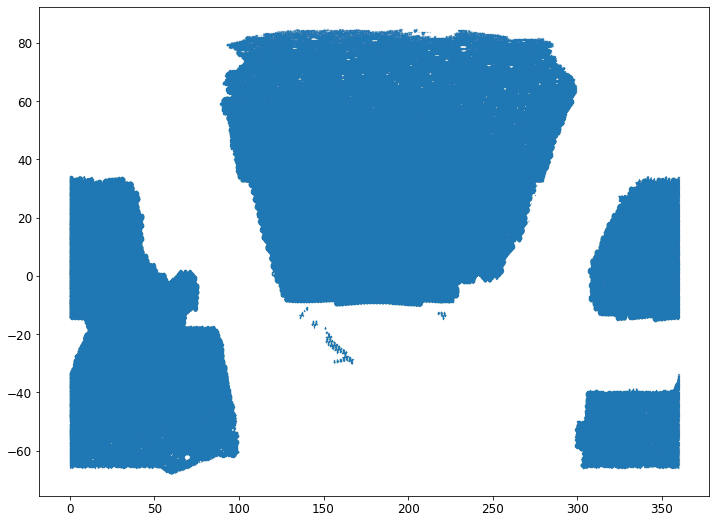

In [6]:
plt.figure(figsize=(12, 9))
plt.plot(cat['RA'], cat['DEC'], '.', ms=0.1)
plt.show()

In [7]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cat['gmag'] = 22.5 - 2.5*np.log10(cat['FLUX_G']) - 3.214 * cat['EBV']
    cat['rmag'] = 22.5 - 2.5*np.log10(cat['FLUX_R']) - 2.165 * cat['EBV']
    cat['zmag'] = 22.5 - 2.5*np.log10(cat['FLUX_Z']) - 1.211 * cat['EBV']
    cat['w1mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W1']) - 0.184 * cat['EBV']
    cat['zfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']) - 1.211 * cat['EBV']

In [8]:
mask_south = cat['PHOTSYS']=='S'
mask_north = cat['PHOTSYS']=='N'

21.6
21.61


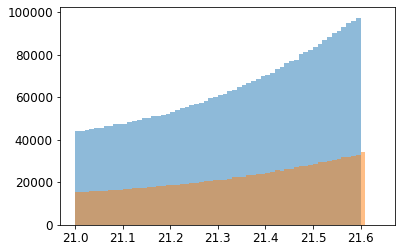

In [9]:
print(np.max(cat['zfibermag'][mask_south]))
print(np.max(cat['zfibermag'][mask_north]))

bins = np.arange(21, 21.65, 0.01)

plt.hist(cat['zfibermag'][mask_south], bins=bins, alpha=0.5)
plt.hist(cat['zfibermag'][mask_north], bins=bins, alpha=0.5)
plt.show()

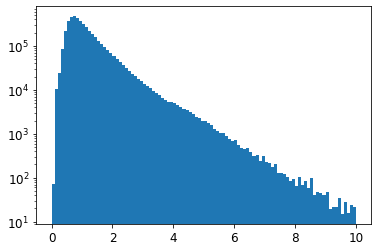

In [10]:
mask = (cat['TYPE']=='DEV')
plt.hist(cat['SHAPE_R'][mask], 100, range=(0, 10), log=True)
plt.show()

----------
# EXP

In [11]:
mask = cat['TYPE']=='EXP'
cat = cat[mask]
print(len(cat))

1039390


In [12]:
# r is radius; y is fiberflux fraction
r, y = cat['SHAPE_R'].copy(), (cat['FIBERFLUX_Z']/cat['FLUX_Z']).copy()

# axis ratio
e = np.array(np.sqrt(cat['SHAPE_E1']**2+cat['SHAPE_E2']**2))
q = (1+e)/(1-e)

In [13]:
print(r.min(), r.max(), q.min(), q.max())

0.01 10.6896 1.0272553 276.06894


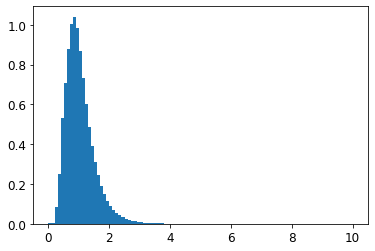

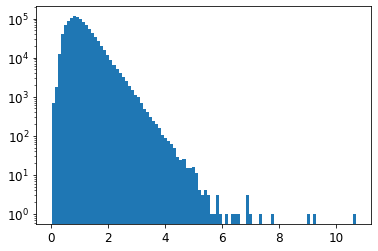

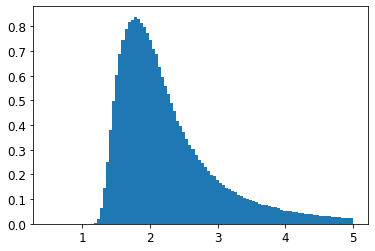

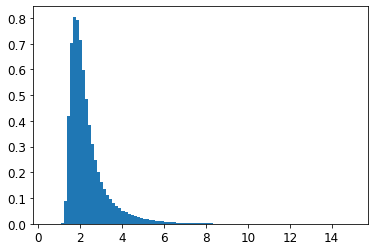

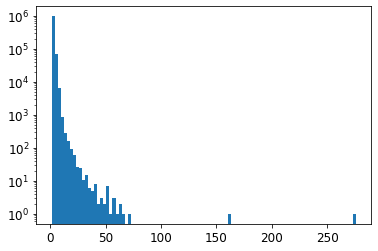

In [14]:
plt.hist(r, 100, range=(0, 10), density=True)
plt.show()

plt.hist(r, 100, log=True)
plt.show()

plt.hist(q, 100, range=(0.5, 5), density=True)
plt.show()

plt.hist(q, 100, range=(0.5, 15), density=True)
plt.show()

plt.hist(q, 100, log=True)
plt.show()

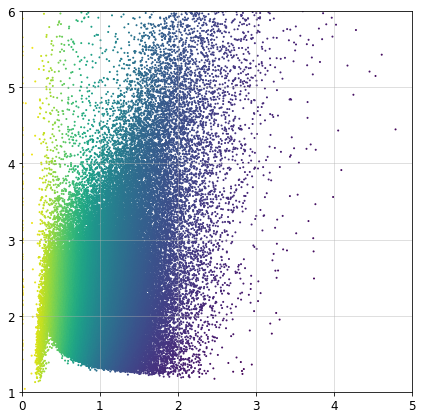

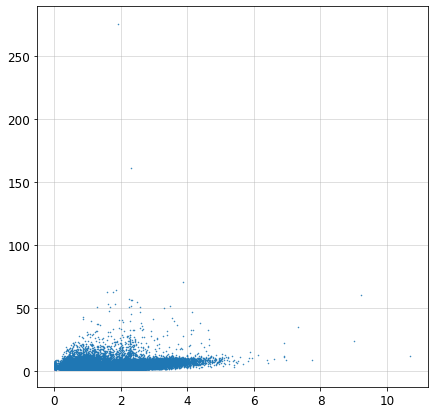

In [15]:
idx = np.random.choice(len(r), size=int(1e5), replace=False)
plt.figure(figsize=(7, 7))
plt.scatter(r[idx], q[idx], c=y[idx], s=1)
plt.axis([0, 5, 1, 6])
plt.grid(alpha=0.5)
plt.show()

plt.figure(figsize=(7, 7))
plt.plot(r, q, '.', ms=1)
plt.grid(alpha=0.5)
plt.show()

In [16]:
rmin, rmax, qmin, qmax = 0., 6., 1., 10.
r_bins = np.arange(rmin, rmax+0.02, 0.02)
q_bins = np.arange(qmin, qmax+0.1, 0.1)
mask = (r>=rmin) & (r<rmax) & (q>=qmin) & (q<qmax)
print(np.sum(~mask), np.sum(~mask)/len(mask))

cat = cat[mask]
print(len(cat))

# r is radius; y is fiberflux fraction
r, y = cat['SHAPE_R'].copy(), (cat['FIBERFLUX_Z']/cat['FLUX_Z']).copy()
# axis ratio
e = np.array(np.sqrt(cat['SHAPE_E1']**2+cat['SHAPE_E2']**2))
q = (1+e)/(1-e)

1217 0.0011708790733026102
1038173


In [17]:
print(len(r_bins), len(q_bins))
ratio_2d, r_center_2d, q_center_2d = np.full((3, len(r_bins)-1, len(q_bins)-1), np.nan)
print(ratio_2d.shape)

r_idx = np.digitize(r, r_bins) - 1
q_idx = np.digitize(q, q_bins) - 1
print(r_idx.min(), r_idx.max(), q_idx.min(), q_idx.max())

301 91
(300, 90)
0 290 0 89


In [18]:
for r_index in np.unique(r_idx):
    if r_index==-1:
        continue
    if r_index%100==0:
        print(r_index)
    mask = (r_idx==r_index)
    if np.sum(mask)==0:
        continue
    tmp = q_idx[mask]
    y_tmp = y[mask]
    r_tmp = r[mask]
    q_tmp = q[mask]
    for q_index in np.unique(q_idx[mask]):
        if q_index==-1:
            continue
        mask1 = (tmp==q_index)
        if np.sum(mask1)==0:
            continue
        ratio_2d[r_index, q_index] = np.mean(y_tmp[mask1])
        r_center_2d[r_index, q_index] = np.mean(r_tmp[mask1])
        q_center_2d[r_index, q_index] = np.mean(q_tmp[mask1])

0
100
200


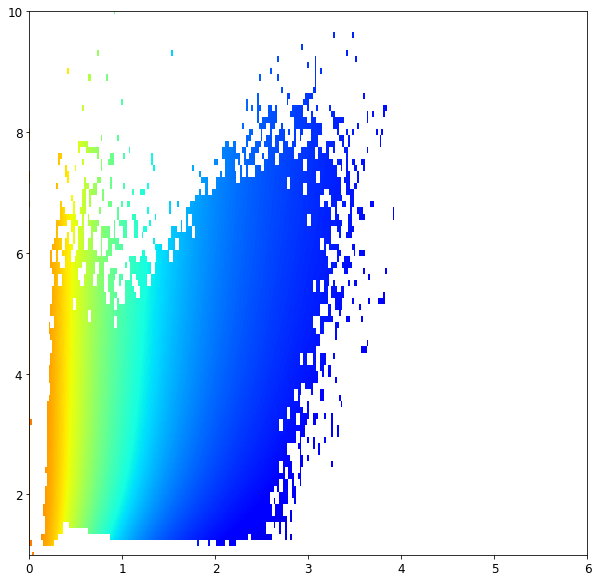

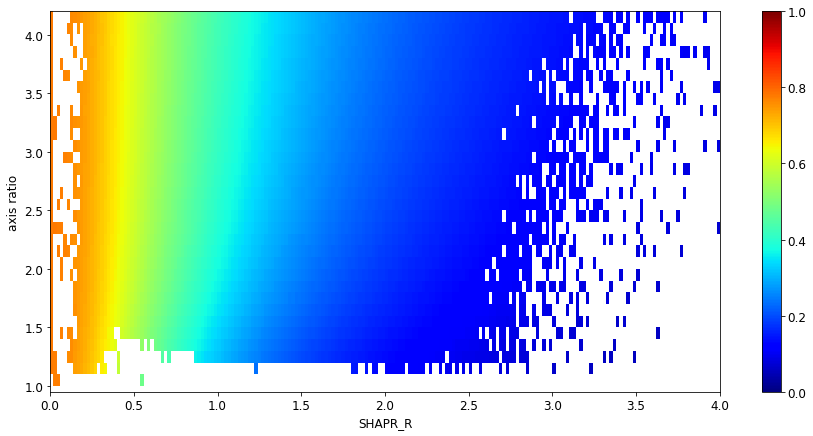

In [19]:
plt.figure(figsize=(10, 10))
plt.imshow(ratio_2d.T, vmin=0, vmax=1, origin='lower', cmap='jet', extent=(r_bins.min(), r_bins.max(), q_bins.min(), q_bins.max()), aspect='auto')
plt.show()

plt.figure(figsize=(15, 7))
plt.imshow(ratio_2d.T, vmin=0, vmax=1, origin='lower', cmap='jet', extent=(r_bins.min(), r_bins.max(), q_bins.min(), q_bins.max()), aspect='auto')
plt.xlabel('SHAPR_R')
plt.ylabel('axis ratio')
plt.axis([0, 4, 0.95, 4.2])
plt.colorbar()
plt.show()

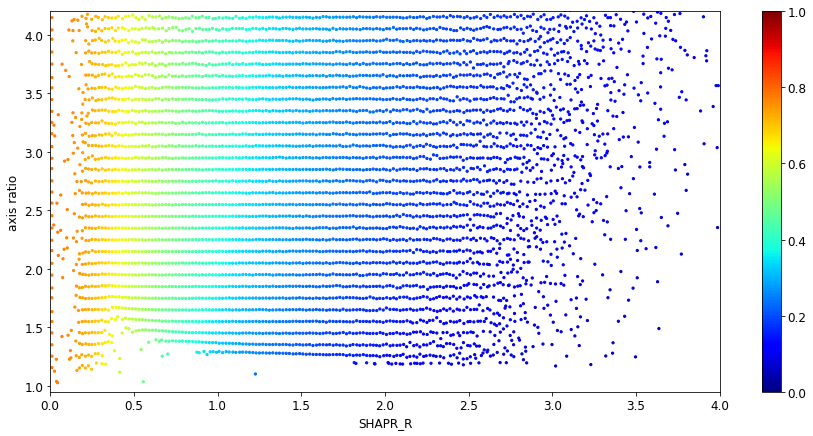

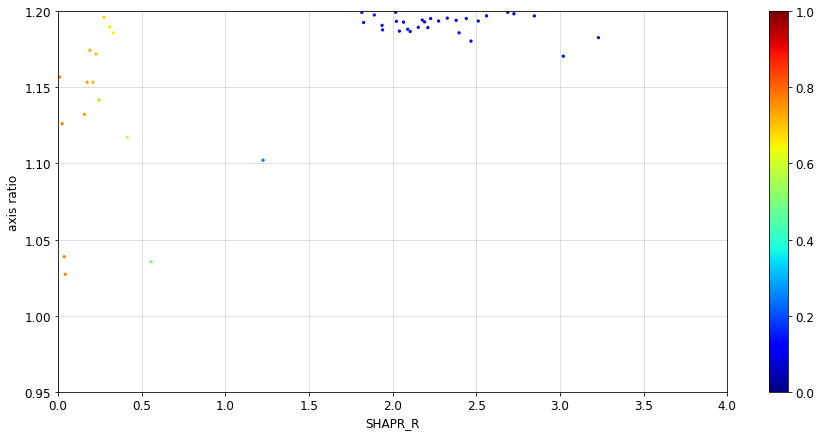

In [20]:
plt.figure(figsize=(15, 7))
plt.scatter(r_center_2d.flatten(), q_center_2d.flatten(), c=ratio_2d.flatten(), s=5, vmin=0, vmax=1, cmap='jet')
plt.axis([0, 4, 0.95, 4.2])
plt.xlabel('SHAPR_R')
plt.ylabel('axis ratio')
plt.colorbar()
plt.show()

plt.figure(figsize=(15, 7))
plt.scatter(r_center_2d.flatten(), q_center_2d.flatten(), c=ratio_2d.flatten(), s=5, vmin=0, vmax=1, cmap='jet')
plt.axis([0, 4, 0.95, 1.2])
plt.xlabel('SHAPR_R')
plt.ylabel('axis ratio')
plt.grid(alpha=0.5)
plt.colorbar()
plt.show()

In [21]:
mask = np.isfinite(ratio_2d)
ratio = ratio_2d[mask]
r_center = r_center_2d[mask]
q_center = q_center_2d[mask]

np.savez('data/exp_fiber_ratio.npz', shape_r=r_center, q=q_center, ratio=ratio)

def ratio_interp(r, q):
    q = np.clip(q, 1.2, 9.95)
    r = np.clip(r, 0., 5.99)
    return griddata(np.array([r_center, q_center]).T, ratio, (r, q), method='cubic')

In [22]:
# r_grid = np.arange(rmin, rmax+0.01, 0.01)
# q_grid = np.arange(qmin, qmax+0.01, 0.01)
r_grid = np.concatenate([[0], (r_bins[1:]+r_bins[:-1])/2])
q_grid = (q_bins[1:]+q_bins[:-1])/2
q_mesh, r_mesh = np.meshgrid(q_grid, r_grid)

ratio_mesh = ratio_interp(r_mesh, q_mesh)

# mask = np.isfinite(ratio_mesh)
# r_mesh_flat = r_mesh[mask]
# q_mesh_flat = q_mesh[mask]
# ratio_mesh_flat = ratio_mesh[mask]

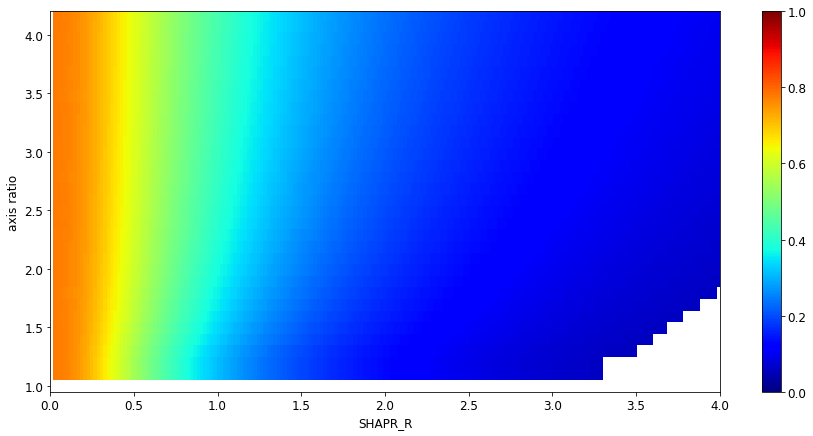

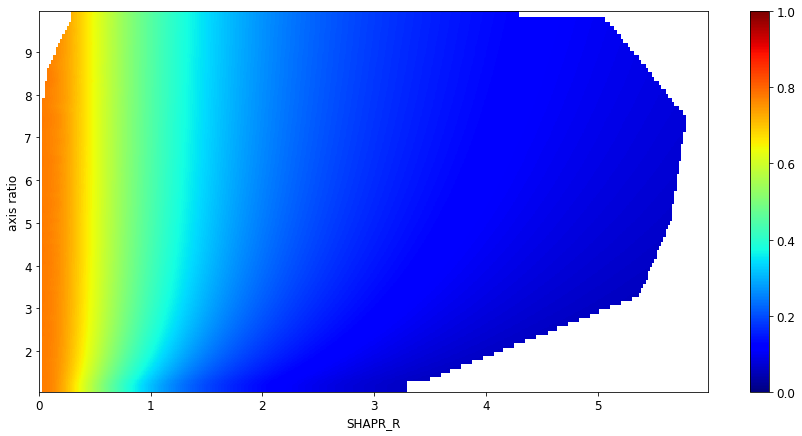

In [23]:
plt.figure(figsize=(15, 7))
plt.imshow(ratio_mesh.T, vmin=0, vmax=1, origin='lower', cmap='jet', extent=(r_grid.min(), r_grid.max(), q_grid.min(), q_grid.max()), aspect='auto')
plt.xlabel('SHAPR_R')
plt.ylabel('axis ratio')
plt.axis([0, 4, 0.95, 4.2])
plt.colorbar()
plt.show()

plt.figure(figsize=(15, 7))
plt.imshow(ratio_mesh.T, vmin=0, vmax=1, origin='lower', cmap='jet', extent=(r_grid.min(), r_grid.max(), q_grid.min(), q_grid.max()), aspect='auto')
plt.xlabel('SHAPR_R')
plt.ylabel('axis ratio')
# plt.axis([0, 4, 0.95, 4.2])
plt.colorbar()
plt.show()

In [24]:
d_radius = 0.001
fplus = ratio_interp(r_mesh*(1+d_radius), q_mesh) * (r_mesh*(1+d_radius))**2
fminus = ratio_interp(r_mesh*(1-d_radius), q_mesh) * (r_mesh*(1-d_radius))**2
epsilon = (1+d_radius)**2 / (1-d_radius)**2 - 1
print(epsilon)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    f_factor_mesh = (fplus/fminus-1) / epsilon
    
f_factor_mesh[0] = 1.  # fiber factor is unit for point source

0.004008012016019746


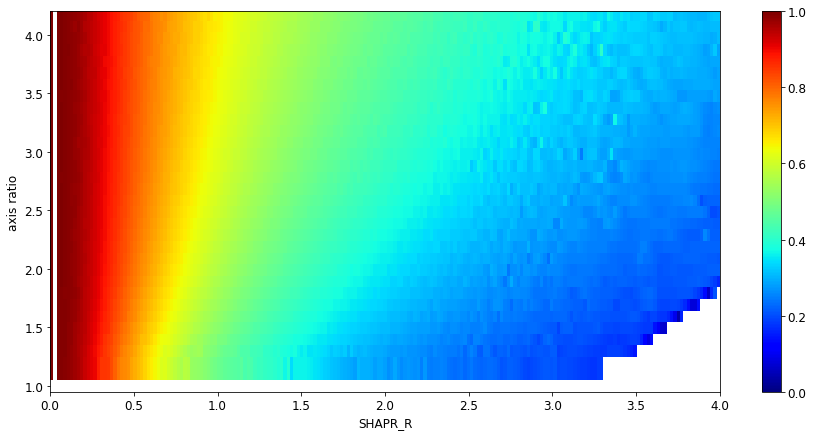

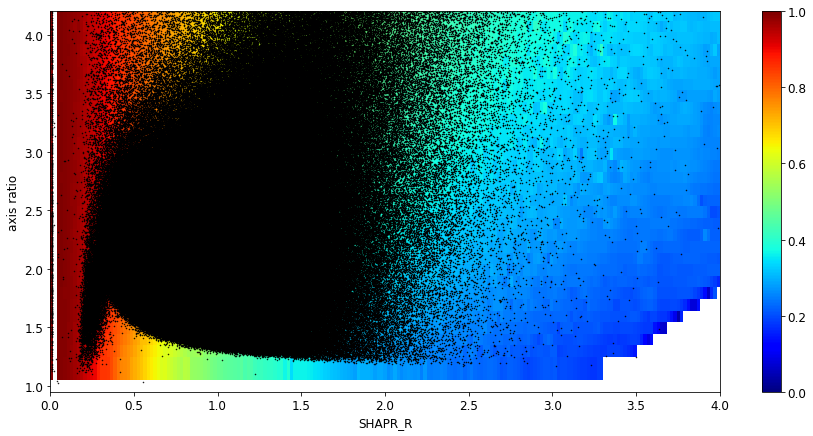

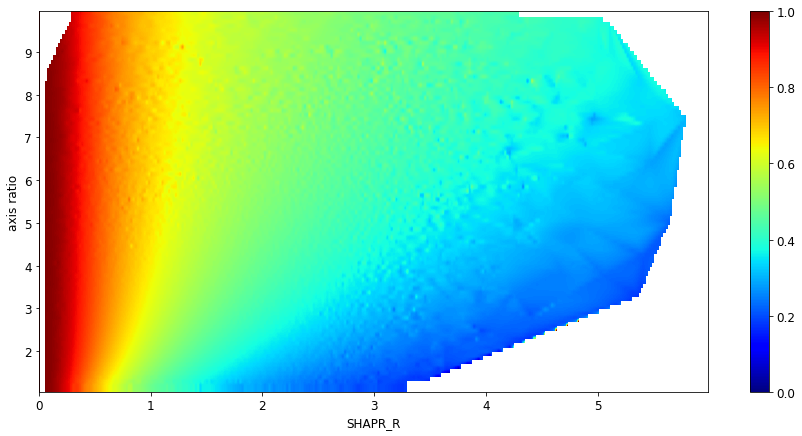

In [25]:
plt.figure(figsize=(15, 7))
plt.imshow(f_factor_mesh.T, vmin=0, vmax=1, origin='lower', cmap='jet', extent=(r_mesh.min(), r_mesh.max(), q_mesh.min(), q_mesh.max()), aspect='auto')
plt.xlabel('SHAPR_R')
plt.ylabel('axis ratio')
plt.axis([0, 4, 0.95, 4.2])
plt.colorbar()
plt.show()

plt.figure(figsize=(15, 7))
plt.imshow(f_factor_mesh.T, vmin=0, vmax=1, origin='lower', cmap='jet', extent=(r_mesh.min(), r_mesh.max(), q_mesh.min(), q_mesh.max()), aspect='auto')
plt.xlabel('SHAPR_R')
plt.ylabel('axis ratio')
plt.axis([0, 4, 0.95, 4.2])
plt.plot(cat['SHAPE_R'], q, '.', ms=1, color='k')
plt.colorbar()
plt.show()

plt.figure(figsize=(15, 7))
plt.imshow(f_factor_mesh.T, vmin=0, vmax=1, origin='lower', cmap='jet', extent=(r_mesh.min(), r_mesh.max(), q_mesh.min(), q_mesh.max()), aspect='auto')
plt.xlabel('SHAPR_R')
plt.ylabel('axis ratio')
# plt.axis([0, 4, 0.95, 4.2])
plt.colorbar()
plt.show()

In [26]:
mask = np.isfinite(f_factor_mesh)
r_mesh_flat0 = r_mesh[mask].copy()
q_mesh_flat0 = q_mesh[mask].copy()
f_factor_mesh_flat = f_factor_mesh[mask].copy()

def f_factor_interp_init(r, q):
    return griddata(np.array([r_mesh_flat0, q_mesh_flat0]).T, f_factor_mesh_flat, (r, q), method='cubic')

f_factor_mesh_smooth = f_factor_interp_init(r_mesh, q_mesh)

for q_index in range(len(q_grid)):
    f = f_factor_mesh[:, q_index].copy()
    mask_nan = np.isfinite(f)
    f = f[mask_nan]
    mask_filter = r_grid[mask_nan]>0.5
    if np.sum(mask_filter)>=31:
        f[mask_filter] = savgol_filter(f, 31, 2)[mask_filter]
        
    # Force the fiber factor to be monotonically decreasing with radius
    f = np.minimum.accumulate(f)

    f_factor_mesh_smooth[:, q_index][mask_nan] = f

mask = np.isfinite(f_factor_mesh_smooth)
r_mesh_flat = r_mesh[mask]
q_mesh_flat = q_mesh[mask]
f_factor_mesh_smooth_flat = f_factor_mesh_smooth[mask]

In [27]:
np.savez('data/exp_fiber_factor.npz', shape_r=r_mesh_flat, q=q_mesh_flat, f_factor=f_factor_mesh_smooth_flat)

data = np.load('data/exp_fiber_factor.npz')
print(data.files)
r_mesh_flat, q_mesh_flat, f_factor_mesh_smooth_flat = data['shape_r'], data['q'], data['f_factor']

['shape_r', 'q', 'f_factor']


In [28]:
def f_factor_interp(r, q):

    q = np.clip(q, 1.2, 9.95)
    r = np.clip(r, 0., 5.99)

    f = griddata(np.array([r_mesh_flat, q_mesh_flat]).T, f_factor_mesh_smooth_flat, (r, q), method='cubic')
    f = np.clip(f, 0., 1.)
    
    return f

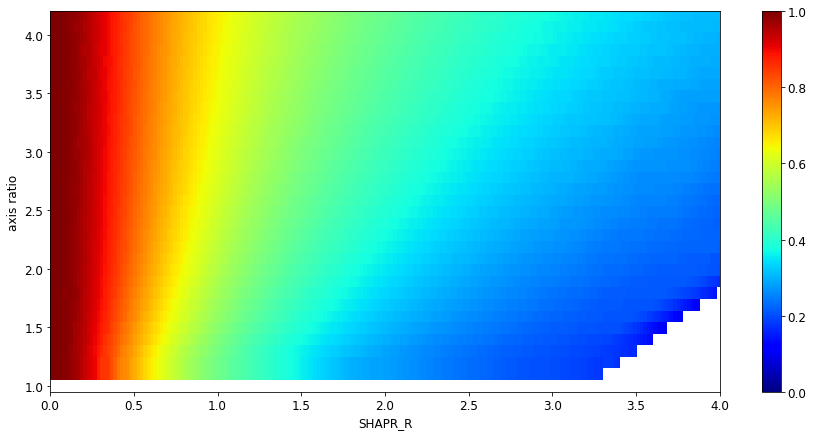

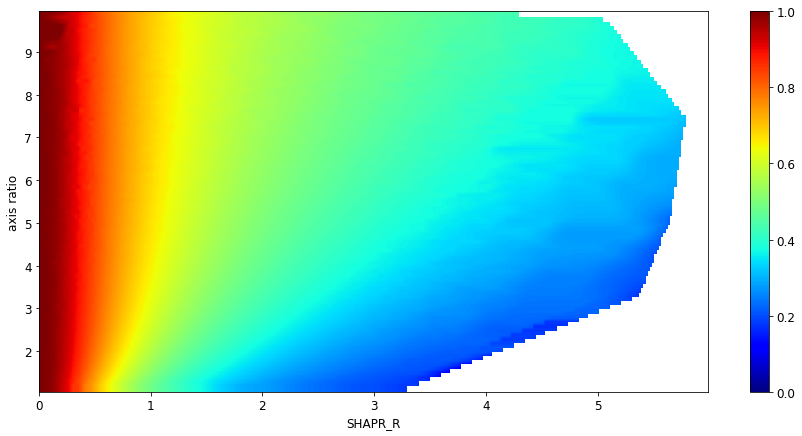

In [29]:
plt.figure(figsize=(15, 7))
plt.imshow(f_factor_mesh_smooth.T, vmin=0, vmax=1, origin='lower', cmap='jet', extent=(r_mesh.min(), r_mesh.max(), q_mesh.min(), q_mesh.max()), aspect='auto')
plt.xlabel('SHAPR_R')
plt.ylabel('axis ratio')
plt.axis([0, 4, 0.95, 4.2])
plt.colorbar()
plt.show()

plt.figure(figsize=(15, 7))
plt.imshow(f_factor_mesh_smooth.T, vmin=0, vmax=1, origin='lower', cmap='jet', extent=(r_mesh.min(), r_mesh.max(), q_mesh.min(), q_mesh.max()), aspect='auto')
plt.xlabel('SHAPR_R')
plt.ylabel('axis ratio')
# plt.axis([0, 4, 0.95, 4.2])
plt.colorbar()
plt.show()

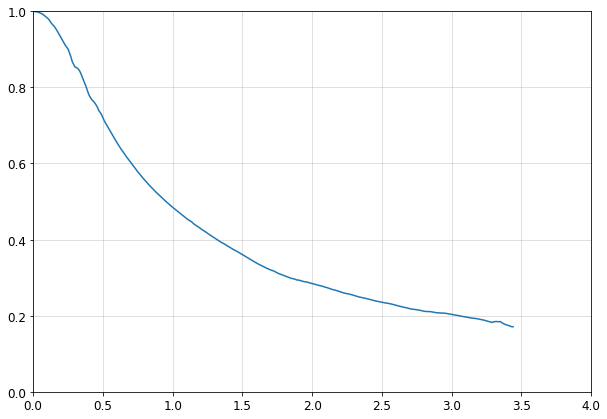

In [30]:
q1 = 1.03
r_plot = np.arange(0., 10+0.01, 0.01)

plt.figure(figsize=(10, 7))
plt.plot(r_plot, f_factor_interp(r_plot, q1))
plt.grid(alpha=0.5)
plt.axis([0, 4, 0., 1])
plt.show()

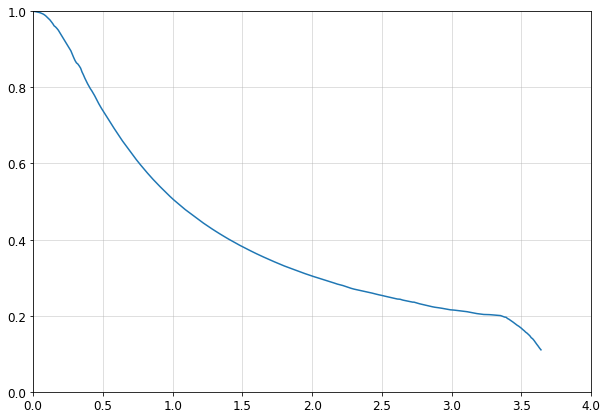

In [31]:
q1 = 1.411
r_plot = np.arange(0., 10+0.01, 0.01)

plt.figure(figsize=(10, 7))
plt.plot(r_plot, f_factor_interp(r_plot, q1))
plt.grid(alpha=0.5)
plt.axis([0, 4, 0., 1])
plt.show()

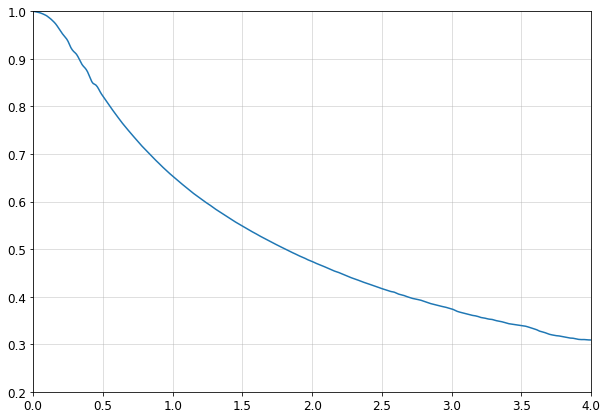

In [32]:
q1 = 4.162
r_plot = np.arange(0., 10+0.01, 0.01)

plt.figure(figsize=(10, 7))
plt.plot(r_plot, f_factor_interp(r_plot, q1))
plt.grid(alpha=0.5)
plt.axis([0, 4, 0.2, 1])
plt.show()

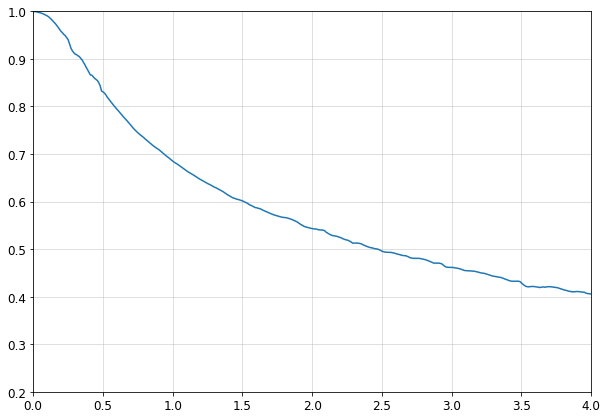

In [33]:
q1 = 7.5
r_plot = np.arange(0., 10+0.01, 0.01)

plt.figure(figsize=(10, 7))
plt.plot(r_plot, f_factor_interp(r_plot, q1))
plt.grid(alpha=0.5)
plt.axis([0, 4, 0.2, 1])
plt.show()

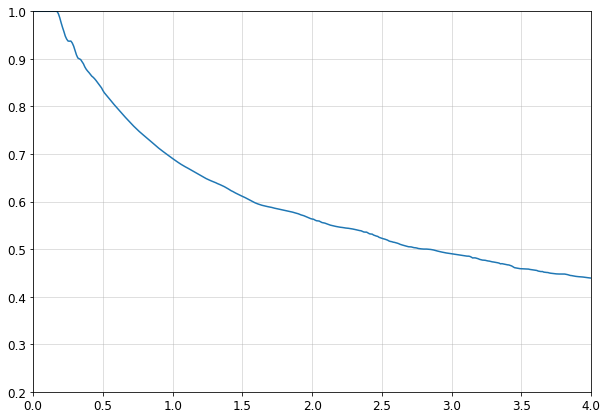

In [34]:
q1 = 9.5
r_plot = np.arange(0., 10+0.01, 0.01)

plt.figure(figsize=(10, 7))
plt.plot(r_plot, f_factor_interp(r_plot, q1))
plt.grid(alpha=0.5)
plt.axis([0, 4, 0.2, 1])
plt.show()

In [35]:
r_grid.min(), r_grid.max(), q_grid.min(), q_grid.max()

(0.0, 5.99, 1.05, 9.950000000000006)